YOLO + BLIP-2 Preprocessing Pipeline
### Visual Product Search Engine | DeepFashion In-Shop Clothes Retrieval

**Pipeline steps:**
1. Traverse dataset folders and collect image paths
2. Detect clothing using YOLOv8 (pretrained, frozen)
3. Crop the detected region (fallback to full image if no detection)
4. Generate semantic captions using BLIP-2 (pretrained, frozen)
5. Save crops + `metadata.csv` for downstream members

> **GPU:** Enable T4 GPU in Kaggle → Settings → Accelerator

In [6]:
import os

input_dir = "/kaggle/input"

max_depth = 7  # Number of subdirectory levels to show

for root, dirs, files in os.walk(input_dir):
    # Calculate current depth
    depth = root[len(input_dir):].count(os.sep)

    if depth > max_depth:
        continue

    indent = "    " * depth
    print(f"{indent}📂 {os.path.basename(root)}")

    # Show only folder names, not all image files
    for d in dirs:
        print(f"{indent}    └── {d}")

📂 input
    └── datasets
    📂 datasets
        └── abhinavkishan123
        📂 abhinavkishan123
            └── deepfashion-inshop-dataset
            📂 deepfashion-inshop-dataset
                └── Dataset
                📂 Dataset
                    └── img
                    📂 img
                        └── img
                        📂 img
                            └── MEN
                            └── WOMEN
                            📂 MEN
                                └── Denim
                                └── Jackets_Vests
                                └── Sweaters
                                └── Shorts
                                └── Pants
                                └── Tees_Tanks
                                └── Sweatshirts_Hoodies
                                └── Suiting
                                └── Shirts_Polos
                            📂 WOMEN
                                └── Graphic_Tees
                                └── Dre

## Cell 1 — Install Dependencies

In [7]:
# Run once. Kaggle already has torch/torchvision.
!pip install -q ultralytics
!pip install -q transformers accelerate bitsandbytes
!pip install -q Pillow pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.7 MB/s eta 0:00:00:00:0100:01


## Cell 2 — Imports & Config

In [8]:
import os
import csv
import json
import warnings
import traceback
from pathlib import Path

import pandas as pd
import torch
from PIL import Image, UnidentifiedImageError
from tqdm.notebook import tqdm
from ultralytics import YOLO
from transformers import Blip2Processor, Blip2ForConditionalGeneration

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# AUTO-DETECT DATASET ROOT
# Walks /kaggle/input looking for any directory that contains
# both a MEN/ and WOMEN/ subdirectory — works for any dataset slug.
# ─────────────────────────────────────────────────────────────────────────────

def find_dataset_root(base: str = "/kaggle/input") -> Path | None:
    for dirpath in sorted(Path(base).rglob("*")):
        if dirpath.is_dir():
            children = {d.name.upper() for d in dirpath.iterdir() if d.is_dir()}
            if "MEN" in children and "WOMEN" in children:
                return dirpath
    return None

_detected = find_dataset_root()

if _detected:
    DATASET_ROOT = _detected
    print(f"✅  Auto-detected dataset root: {DATASET_ROOT}")
else:
    # ── fallback: set manually if auto-detect fails ───────────────────────────
    # Run Cell 1 above to see the full /kaggle/input tree, then paste the
    # folder that contains MEN/ and WOMEN/ here.
    DATASET_ROOT = Path("/kaggle/input/CHANGE-ME/img/img")
    print("⚠️  Auto-detect failed. Set DATASET_ROOT manually above.")
    print("    Run Cell 1 to see available paths under /kaggle/input")

# ─────────────────────────────────────────────────────────────────────────────
# OUTPUT PATHS
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR   = Path("/kaggle/working/processed")
CROPS_DIR    = OUTPUT_DIR / "crops"
METADATA_CSV = OUTPUT_DIR / "metadata.csv"

# ─────────────────────────────────────────────────────────────────────────────
# YOLO SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
YOLO_MODEL       = "yolov8n.pt"   # nano — fast; swap to yolov8s.pt for better accuracy
YOLO_CONF        = 0.25           # confidence threshold
YOLO_IOU         = 0.45           # NMS IoU threshold
CLOTHING_CLASSES = [0]            # COCO class 0 = person (proxy for clothing region)

# ─────────────────────────────────────────────────────────────────────────────
# BLIP-2 SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
BLIP2_MODEL          = "Salesforce/blip2-opt-2.7b"   # ~6 GB fp16 — fits on Kaggle T4
BLIP2_PROMPT         = "Question: What clothing item is shown? Answer:"
BLIP2_MAX_NEW_TOKENS = 40
BLIP2_BATCH          = 4   # images per BLIP-2 forward pass; reduce to 1 if OOM

# Crop padding (fraction of box dimension added on each side)
CROP_PADDING = 0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device : {DEVICE}")
print(f"Dataset: {DATASET_ROOT}")
print(f"Output : {OUTPUT_DIR}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CROPS_DIR.mkdir(parents=True, exist_ok=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅  Auto-detected dataset root: /kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset/img/img
Device : cuda
Dataset: /kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset/img/img
Output : /kaggle/working/processed


## Cell 3 — Verify Dataset Path

In [9]:
# Verify the detected path is correct
if not DATASET_ROOT.exists():
    print(f"❌  Path not found: {DATASET_ROOT}")
    print()
    print("Full /kaggle/input tree (use this to find the correct path):")
    for p in sorted(Path("/kaggle/input").rglob("*")):
        if p.is_dir():
            depth = len(p.relative_to("/kaggle/input").parts)
            if depth <= 5:
                print("  " * depth + "📂 " + p.name)
    print()
    raise FileNotFoundError(
        "Update the manual fallback path in Cell 2 (search for CHANGE-ME), "
        "then re-run Cell 2 and this cell."
    )

top_folders = sorted(DATASET_ROOT.iterdir())
print(f"✅  Dataset root found: {DATASET_ROOT}")
print(f"   Top-level folders ({len(top_folders)}):")
for f in top_folders:
    print("  ", f.name)


✅  Dataset root found: /kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset/img/img
   Top-level folders (2):
   MEN
   WOMEN


## Cell 4 — Dataset Traversal
Collects every image path and extracts `gender`, `category`, `item_id`.

In [10]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

def collect_images(dataset_root: Path) -> pd.DataFrame:
    """
    Walk  dataset_root / {GENDER} / {CATEGORY} / {ITEM_ID} / *.jpg
    Returns a DataFrame with columns:
        image_path, item_id, gender, category
    """
    records = []
    for gender_dir in sorted(dataset_root.iterdir()):
        if not gender_dir.is_dir():
            continue
        gender = gender_dir.name.upper()          # MEN / WOMEN

        for cat_dir in sorted(gender_dir.iterdir()):
            if not cat_dir.is_dir():
                continue
            category = cat_dir.name               # Denim / Dresses / …

            for item_dir in sorted(cat_dir.iterdir()):
                if not item_dir.is_dir():
                    continue
                item_id = item_dir.name           # id_00000080

                for img_file in sorted(item_dir.iterdir()):
                    if img_file.suffix.lower() in VALID_EXTENSIONS:
                        records.append({
                            "image_path": str(img_file),
                            "item_id"   : item_id,
                            "gender"    : gender,
                            "category"  : category,
                        })
    return pd.DataFrame(records)


image_df = collect_images(DATASET_ROOT)
print(f"✅  Collected {len(image_df):,} images across "
      f"{image_df['item_id'].nunique():,} item IDs")
print()
print(image_df.groupby(["gender", "category"]).size()
              .reset_index(name="count")
              .to_string(index=False))

✅  Collected 52,712 images across 7,982 item IDs

gender            category  count
   MEN               Denim    411
   MEN       Jackets_Vests    424
   MEN               Pants   1017
   MEN        Shirts_Polos    722
   MEN              Shorts   1000
   MEN             Suiting     39
   MEN            Sweaters    605
   MEN Sweatshirts_Hoodies    775
   MEN          Tees_Tanks   2845
 WOMEN      Blouses_Shirts   7964
 WOMEN           Cardigans   1436
 WOMEN               Denim    393
 WOMEN             Dresses   6999
 WOMEN        Graphic_Tees   1297
 WOMEN       Jackets_Coats   1895
 WOMEN            Leggings    335
 WOMEN               Pants   1804
 WOMEN   Rompers_Jumpsuits   1696
 WOMEN              Shorts   3476
 WOMEN              Skirts   2045
 WOMEN            Sweaters   3036
 WOMEN Sweatshirts_Hoodies    856
 WOMEN          Tees_Tanks  11642


## Cell 5 — Load YOLO Model

In [11]:
print(f"Loading YOLO model: {YOLO_MODEL} ...")
yolo_model = YOLO(YOLO_MODEL)   # downloads automatically on first run
print("✅  YOLO ready")

Loading YOLO model: yolov8n.pt ...
✅  YOLO ready


## Cell 6 — YOLO Detection Helper

In [12]:
def detect_and_crop(
    img: Image.Image,
    image_path: str,
    padding: float = CROP_PADDING,
) -> tuple[Image.Image, dict]:
    """
    Run YOLO on `img`.  Returns (cropped_image, info_dict).

    info_dict keys: bbox, confidence, detection_status
    detection_status: 'success' | 'fallback_original' | 'failed'
    """
    W, H = img.size

    results = yolo_model.predict(
        source       = img,
        conf         = YOLO_CONF,
        iou          = YOLO_IOU,
        classes      = CLOTHING_CLASSES,
        verbose      = False,
        device       = DEVICE,
    )

    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        # No detection → fallback to full image
        return img, {
            "bbox"            : None,
            "confidence"      : None,
            "detection_status": "fallback_original",
        }

    # Pick the box with the highest confidence
    best_idx  = boxes.conf.argmax().item()
    conf      = float(boxes.conf[best_idx])
    x1, y1, x2, y2 = boxes.xyxy[best_idx].tolist()

    # Add padding
    bw, bh = x2 - x1, y2 - y1
    x1 = max(0, x1 - padding * bw)
    y1 = max(0, y1 - padding * bh)
    x2 = min(W, x2 + padding * bw)
    y2 = min(H, y2 + padding * bh)

    bbox = [round(x1), round(y1), round(x2), round(y2)]
    crop = img.crop(bbox)

    return crop, {
        "bbox"            : bbox,
        "confidence"      : round(conf, 4),
        "detection_status": "success",
    }


print("✅  YOLO helper defined")

✅  YOLO helper defined


## Cell 7 — Load BLIP-2 Model
Loaded in **float16** to fit on the Kaggle T4 (16 GB VRAM).  
If you see an OOM error, uncomment the `load_in_8bit=True` line instead.

In [13]:
print(f"Loading BLIP-2 processor: {BLIP2_MODEL} ...")
blip2_processor = Blip2Processor.from_pretrained(BLIP2_MODEL)

print("Loading BLIP-2 model weights (fp16) — this takes ~1-2 minutes ...")
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_MODEL,
    torch_dtype = torch.float16,
    device_map  = "auto",          # automatically places layers on GPU/CPU
    # load_in_8bit = True,         # ← uncomment if fp16 causes OOM
)
blip2_model.eval()

print("✅  BLIP-2 ready")
if DEVICE == "cuda":
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved()  / 1e9
    print(f"    GPU memory — allocated: {allocated:.2f} GB | reserved: {reserved:.2f} GB")

Loading BLIP-2 processor: Salesforce/blip2-opt-2.7b ...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✅  BLIP-2 ready
    GPU memory — allocated: 3.93 GB | reserved: 3.95 GB


## Cell 8 — BLIP-2 Caption Helper

In [14]:
@torch.inference_mode()
def generate_captions(crops: list[Image.Image]) -> list[str]:
    """
    Generate one clothing caption per crop image.
    Processes in a single batch for efficiency.

    The prompt guides BLIP-2 toward product-style captions
    (e.g. "black denim jeans") rather than scene descriptions.
    """
    prompts = [BLIP2_PROMPT] * len(crops)

    inputs = blip2_processor(
        images = crops,
        text   = prompts,
        return_tensors = "pt",
        padding        = True,
    ).to(DEVICE, torch.float16)

    out = blip2_model.generate(
        **inputs,
        max_new_tokens = BLIP2_MAX_NEW_TOKENS,
        do_sample      = False,    # greedy — deterministic captions
    )

    captions = blip2_processor.batch_decode(out, skip_special_tokens=True)

    # Strip the echoed prompt prefix if present
    cleaned = []
    prefix  = "Answer:"
    for cap in captions:
        if prefix in cap:
            cap = cap.split(prefix, 1)[-1]
        cleaned.append(cap.strip())

    return cleaned


print("✅  BLIP-2 caption helper defined")

✅  BLIP-2 caption helper defined


## Cell 9 — Quick Smoke Test (3 images)
Run this before the full pipeline to make sure everything works.

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

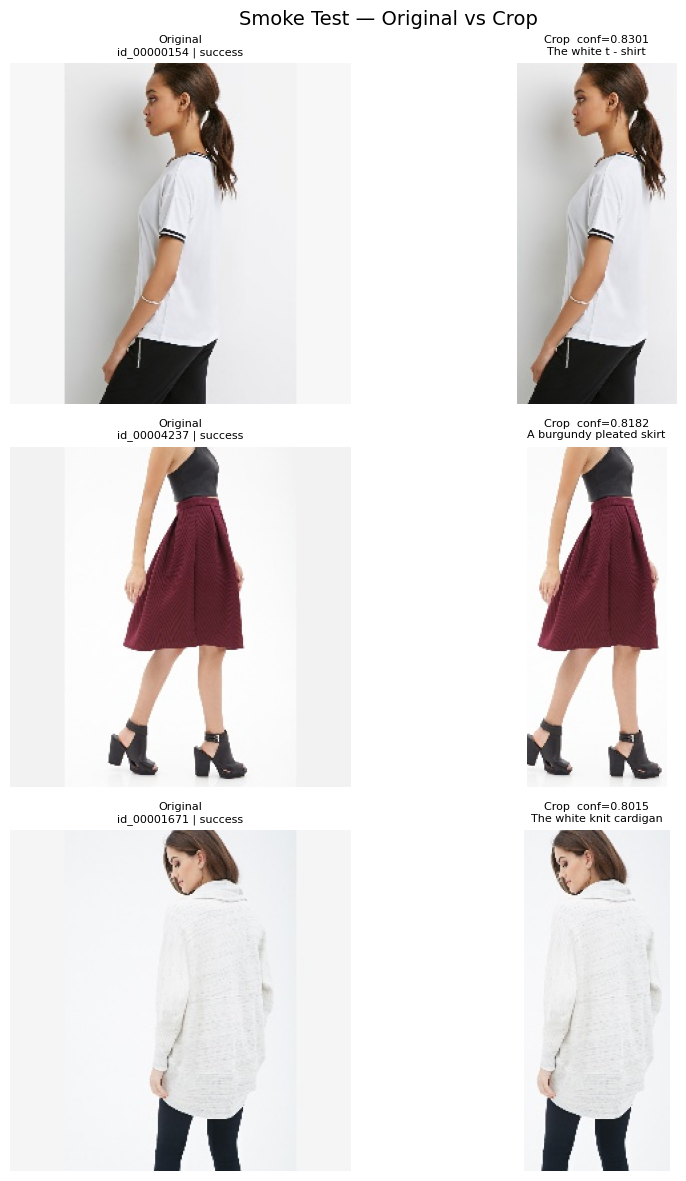

✅  Smoke test passed


In [15]:
import matplotlib.pyplot as plt

test_rows = image_df.sample(3, random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle("Smoke Test — Original vs Crop", fontsize=14)

for i, (_, row) in enumerate(test_rows.iterrows()):
    img  = Image.open(row["image_path"]).convert("RGB")
    crop, info = detect_and_crop(img, row["image_path"])

    # Single-image BLIP-2 call for the test
    caption = generate_captions([crop])[0]

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original\n{row['item_id']} | {info['detection_status']}",
                         fontsize=8)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(crop)
    axes[i, 1].set_title(f"Crop  conf={info['confidence']}\n{caption}", fontsize=8)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/smoke_test.png", dpi=100)
plt.show()
print("✅  Smoke test passed")

## Cell 10 — Full Pipeline

Processes every image in `image_df`:
- YOLO detection → crop
- BLIP-2 captioning (batched)
- Saves crops & appends rows to `metadata.csv`

**Resume support:** already-processed images are skipped automatically.

In [20]:
CSV_COLUMNS = [
    "image_path", "item_id", "gender", "category",
    "crop_path", "caption", "bbox", "confidence", "detection_status",
]

# ── Resume: load already-processed image paths ──────────────────────────────
processed_paths: set[str] = set()
if METADATA_CSV.exists():
    existing = pd.read_csv(METADATA_CSV)
    processed_paths = set(existing["image_path"].tolist())
    print(f"↩  Resuming: {len(processed_paths):,} images already done.")

# Open CSV in append mode (write header only if file is new)
csv_is_new = not METADATA_CSV.exists()
csv_file   = open(METADATA_CSV, "a", newline="", encoding="utf-8")
writer     = csv.DictWriter(csv_file, fieldnames=CSV_COLUMNS)
if csv_is_new:
    writer.writeheader()
    csv_file.flush()

# ── Filter to-do list ───────────────────────────────────────────────────────
todo_df = image_df[~image_df["image_path"].isin(processed_paths)].reset_index(drop=True)
print(f"Processing {len(todo_df):,} remaining images in batches of {BLIP2_BATCH} ...")

# ── Main loop ───────────────────────────────────────────────────────────────
FLUSH_EVERY = 100   # write to disk every N images
n_written   = 0

for batch_start in tqdm(range(0, len(todo_df), BLIP2_BATCH), desc="Batches"):
    batch = todo_df.iloc[batch_start : batch_start + BLIP2_BATCH]

    # ── 1. Load images & run YOLO ────────────────────────────────────────
    pil_images   : list[Image.Image] = []
    crop_images  : list[Image.Image] = []
    detect_infos : list[dict]        = []
    valid_rows   : list[dict]        = []        # rows that didn't fail

    for _, row in batch.iterrows():
        img_path = row["image_path"]
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            # Corrupted image → write a 'failed' row and skip
            writer.writerow({
                "image_path"      : img_path,
                "item_id"         : row["item_id"],
                "gender"          : row["gender"],
                "category"        : row["category"],
                "crop_path"       : "",
                "caption"         : "",
                "bbox"            : "",
                "confidence"      : "",
                "detection_status": "failed",
            })
            n_written += 1
            continue

        crop, info = detect_and_crop(img, img_path)

        pil_images.append(img)
        crop_images.append(crop)
        detect_infos.append(info)
        valid_rows.append(row.to_dict())

    if not crop_images:
        continue   # entire batch was corrupted

    # ── 2. BLIP-2 captioning (batch) ─────────────────────────────────────
    try:
        captions = generate_captions(crop_images)
    except Exception as e:
        # If BLIP-2 fails on a batch, fall back to per-image generation
        captions = []
        for crop in crop_images:
            try:
                cap = generate_captions([crop])[0]
            except Exception:
                cap = ""
            captions.append(cap)

    # ── 3. Save crops & write CSV rows ───────────────────────────────────
    for row_dict, crop, info, caption in zip(valid_rows, crop_images, detect_infos, captions):
        img_path = row_dict["image_path"]
        item_id  = row_dict["item_id"]

        # Build crop save path mirroring deliverable structure
        # processed/crops/{item_id}/{original_filename}
        original_filename = Path(img_path).name
        item_crop_dir     = CROPS_DIR / item_id
        item_crop_dir.mkdir(parents=True, exist_ok=True)
        crop_path         = item_crop_dir / original_filename

        # Save crop image (JPEG, quality 95)
        try:
            crop.save(str(crop_path), format="JPEG", quality=95)
        except Exception:
            pass  # if save fails, still log the row

        writer.writerow({
            "image_path"      : img_path,
            "item_id"         : item_id,
            "gender"          : row_dict["gender"],
            "category"        : row_dict["category"],
            "crop_path"       : str(crop_path),
            "caption"         : caption,
            "bbox"            : json.dumps(info["bbox"], separators=(',', ':')) if info["bbox"] else "",
            "confidence"      : info["confidence"] if info["confidence"] is not None else "",
            "detection_status": info["detection_status"],
        })
        n_written += 1

    # Flush periodically so progress survives interrupts
    if n_written % FLUSH_EVERY == 0:
        csv_file.flush()

csv_file.flush()
csv_file.close()
print(f"\n✅  Pipeline complete! Wrote {n_written:,} rows to {METADATA_CSV}")

↩  Resuming: 52,712 images already done.
Processing 0 remaining images in batches of 4 ...


Batches: 0it [00:00, ?it/s]


✅  Pipeline complete! Wrote 0 rows to /kaggle/working/processed/metadata.csv


## Cell 11 — Verify & Summarise Output

In [21]:
meta = pd.read_csv(METADATA_CSV)

print("=" * 55)
print("  metadata.csv — Summary")
print("=" * 55)
print(f"  Total rows     : {len(meta):,}")
print(f"  Unique item IDs: {meta['item_id'].nunique():,}")
print()
print("  Detection status breakdown:")
print(meta["detection_status"].value_counts().to_string())
print()
print("  Gender split:")
print(meta["gender"].value_counts().to_string())
print()
print("  Category split (top 10):")
print(meta["category"].value_counts().head(10).to_string())
print()
print("  Sample captions:")
success_rows = meta[meta["detection_status"] == "success"]
print(success_rows[["item_id", "caption"]].sample(5, random_state=0)
                                           .to_string(index=False))
print("=" * 55)

print("\n✅  Integration contract check:")
required_cols = {"image_path", "item_id", "gender", "category",
                 "crop_path", "caption", "bbox", "confidence", "detection_status"}
missing = required_cols - set(meta.columns)
if missing:
    print(f"❌  Missing columns: {missing}")
else:
    print("  All required columns present ✔")
    print("  Next member can load with:")
    print("    df = pd.read_csv('metadata.csv')")
    print("    # Access: df['crop_path'], df['caption'], df['item_id']")

  metadata.csv — Summary
  Total rows     : 52,712
  Unique item IDs: 7,982

  Detection status breakdown:
detection_status
success              50674
fallback_original     2038

  Gender split:
gender
WOMEN    44874
MEN       7838

  Category split (top 10):
category
Tees_Tanks             14487
Blouses_Shirts          7964
Dresses                 6999
Shorts                  4476
Sweaters                3641
Pants                   2821
Skirts                  2045
Jackets_Coats           1895
Rompers_Jumpsuits       1696
Sweatshirts_Hoodies     1631

  Sample captions:
    item_id                   caption
id_00005185                 The skirt
id_00006912                      Blue
id_00007830 The floral print tank top
id_00003075           The blue romper
id_00000775                The hoodie

✅  Integration contract check:
  All required columns present ✔
  Next member can load with:
    df = pd.read_csv('metadata.csv')
    # Access: df['crop_path'], df['caption'], df['item_id']


## Cell 12 — Visualise Random Samples from Output

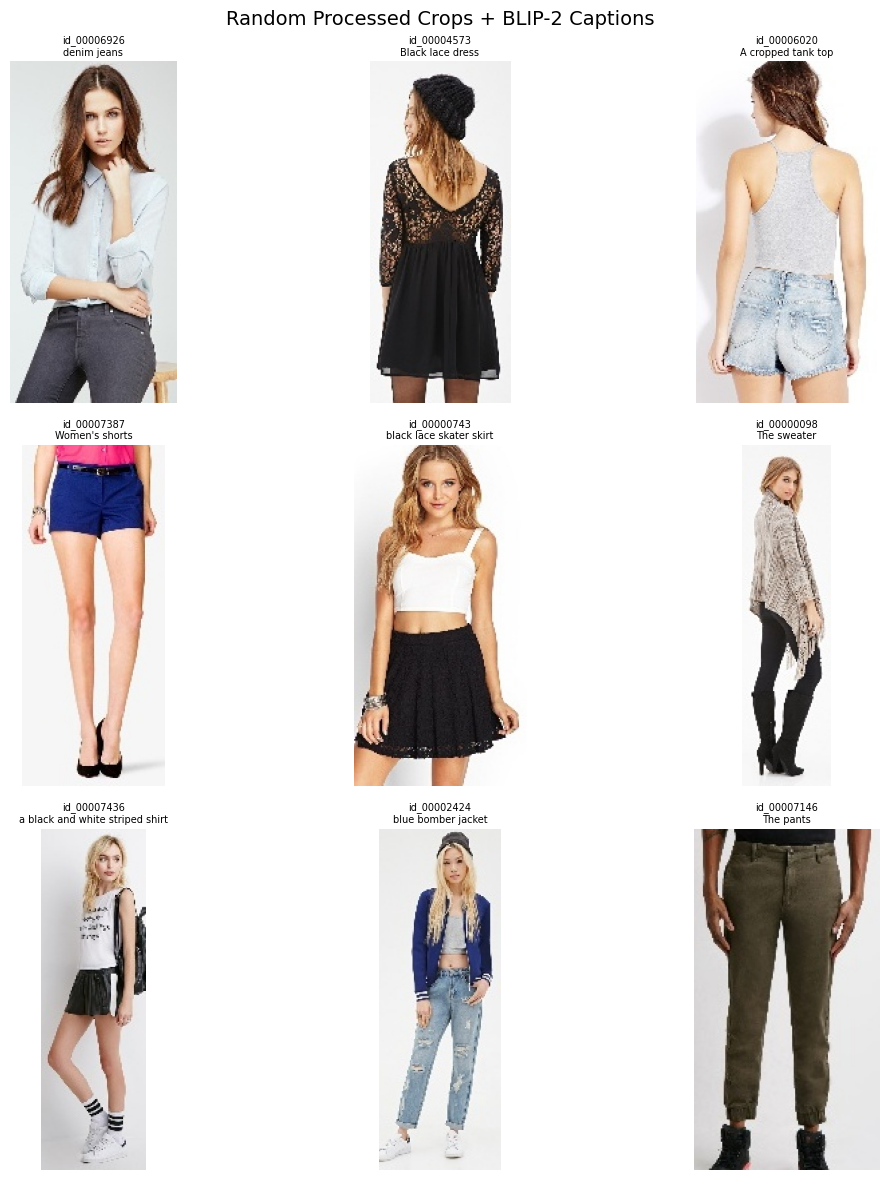

In [22]:
import matplotlib.pyplot as plt

sample = meta[meta["detection_status"] == "success"].sample(9, random_state=7)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Random Processed Crops + BLIP-2 Captions", fontsize=14)

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    try:
        crop = Image.open(row["crop_path"]).convert("RGB")
    except Exception:
        crop = Image.new("RGB", (224, 224), color=(200, 200, 200))

    ax.imshow(crop)
    title = f"{row['item_id']}\n{row['caption'][:55]}"
    ax.set_title(title, fontsize=7, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/sample_results.png", dpi=100)
plt.show()

## Cell 13 — (Optional) Export for Offline Use
Saves `metadata.csv` as a standalone Kaggle output you can share with teammates.

In [23]:
# Copy metadata.csv to /kaggle/working root so it appears in Outputs tab
import shutil

dest = Path("/kaggle/working/metadata.csv")
if METADATA_CSV != dest:
    shutil.copy(METADATA_CSV, dest)

print(f"✅  metadata.csv available in Kaggle Outputs → {dest}")
print(f"   Size: {dest.stat().st_size / 1e6:.2f} MB")
print(f"   Rows: {len(pd.read_csv(dest)):,}")

✅  metadata.csv available in Kaggle Outputs → /kaggle/working/metadata.csv
   Size: 14.24 MB
   Rows: 52,712
